# 02d — Mid-level PLS + SVM-RBF fusion classifier

**CAC2026 Data Challenge — olive oil musty-defect detection (scored by F1).**

Same mid-level data-fusion pipeline, but the final classifier on the fused scores
is an **SVM with an RBF kernel** — the first *regularised* non-linear head:

```
X_hsms ──PLS-DA(LV)──► T_hsms ┐
X_mir  ──PLS-DA(LV)──► T_mir  ├─ hstack ─► scale ─► SVM-RBF ─► musty / not-musty
X_uvvis──PLS-DA(LV)──► T_uvvis┘
```

Unlike QDA (02c), SVM-RBF doesn't estimate per-class covariances, so it can probe
non-linear structure in the **full** fused space without the conditioning
blow-up — its `C` / `gamma` knobs control flexibility explicitly.

This run is the decider: if SVM-RBF *also* stalls near the linear-head ceiling,
the limit is the **features** (preprocessing / regions), not the classifier.

> References so far — 02a PLS-DA **0.765**, 02b LDA **0.755**, 02c QDA **0.688**.

In [1]:
import warnings
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
)

# Quiet sklearn's convergence / undefined-metric chatter during the CV sweeps.
warnings.filterwarnings("ignore")

from olive_oil import (
    load_dataset,
    BlockConfig,
    prepare_blocks,
    MidLevelFusionClassifier,
    nested_cv,
    tune_final_model,
    predict_test,
    make_cv,
)
from olive_oil.visualization import plot_spectra

# Resolve the project root whether the notebook runs from Notebooks/ or the root.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "Data" / "CAC2026_Data_challenge.xlsx"
DATA_PATH

WindowsPath('C:/Users/SamdGuizani/OneDrive/Documents/Data Science & Coding/2026-Olive Oil Classification (CAC 2026)/CAC-2026_Data-Challenge_Olive-Oil-Sensory-Defects-Detection-Using-Chemometrics/Data/CAC2026_Data_challenge.xlsx')

## 1. Load the data

In [2]:
raw = load_dataset(DATA_PATH)
labels = raw["labels"]
print("Calibration samples:", labels.shape[0])
print("Class balance (0 = not musty, 1 = musty):",
      labels["label"].value_counts().sort_index().to_dict())
print("Musty prevalence:", round(labels["label"].mean(), 3))

Calibration samples: 220
Class balance (0 = not musty, 1 = musty): {0: 144, 1: 76}
Musty prevalence: 0.345


## 2. Configure the blocks

Identical block windows / preprocessing to 02a–02c (clean classifier comparison).

In [3]:
# Per-block spectral window + preprocessing recipe (same as 02a best run).
configs = {
    "hsms": BlockConfig(
        region=(100, 125),
        steps=["row_profile", "log", "mean_center"],
    ),
    "mir": BlockConfig(
        region=(1500, 700),
        steps=["snv",
               ("savgol_derivative", {"deriv": 1, "polyorder": 2, "half_window": 6}),
               "mean_center"],
    ),
    "uvvis": BlockConfig(
        region=(300, 1000),
        steps=["snv",
               ("savgol_derivative", {"deriv": 1, "polyorder": 2, "half_window": 6}),
               "mean_center"],
    ),
}

# Calibration sample IDs to discard as outliers (default: none).
outliers = []

data = prepare_blocks(raw, configs, outliers=outliers)
print("Discarded outliers:", data.discarded_ids or "none")
print("Block order:", data.block_names)
data.summary()

Discarded outliers: none
Block order: ['hsms', 'mir', 'uvvis']


,n_variables,axis_min,axis_max,n_train,n_test
block,,,,,
hsms,26,100.00000,125.000000,220,24
mir,208,700.04498,1498.443334,220,24
uvvis,701,300.00000,1000.000000,220,24


### Sanity-check the preprocessed spectra (optional)

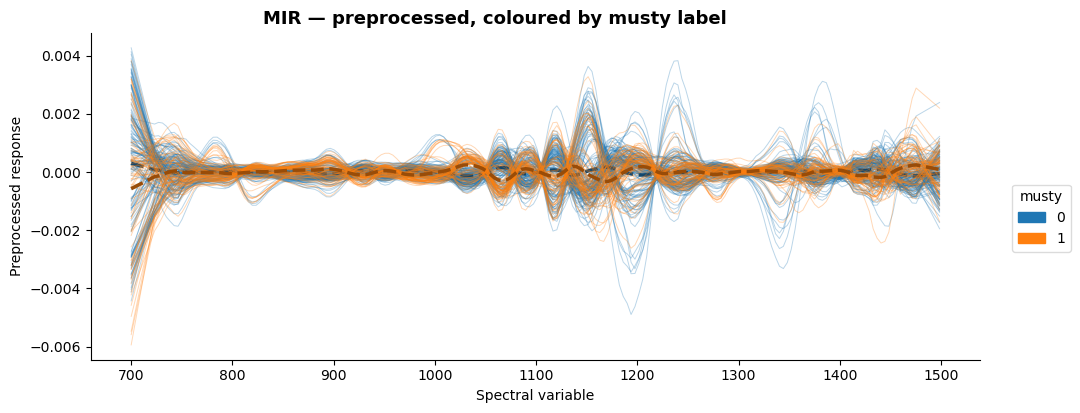

In [4]:
block = "mir"  # try "hsms" / "uvvis" too
i = data.block_names.index(block)
spectra = (data.X_train[i], data.axes[block], data.train_ids)
label_meta = raw["labels"].rename(columns={"label": "musty"})

g = plot_spectra(
    spectra, metadata=label_meta, color_by="musty",
    xlabel="Spectral variable", ylabel="Preprocessed response",
    title=f"{block.upper()} — preprocessed, coloured by musty label",
)

## 3. Build the coarse hyperparameter grid

SVM-RBF adds two tunable knobs to the block latent variables:

| Hyperparameter | Meaning | Coarse range |
|---|---|---|
| `n_components_list[0]` (hsms) | block PLS-DA latent variables | `4, 8, 12` |
| `n_components_list[1]` (mir)  | block PLS-DA latent variables | `9, 15, 21` |
| `n_components_list[2]` (uvvis)| block PLS-DA latent variables | `6, 9, 12` |
| `classifier__C`               | SVM penalty (inverse regularisation) | `0.1, 1, 10, 100` |
| `classifier__gamma`           | RBF kernel width | `scale, 0.001, 0.01, 0.1` |

The block grid is coarser than 02a–02c because two extra dimensions (`C`, `gamma`)
multiply the configuration count. `scale_fused` is **fixed to `True`** here — an
RBF kernel is distance-based, so standardising the fused scores is essential, not
an optional toggle.

In [5]:
# Per-block latent-variable ranges (coarse, trimmed to offset the C/gamma sweep).
LV_HSMS  = (4, 8, 12)
LV_MIR   = (9, 15, 21)
LV_UVVIS = (6, 9, 12)

component_grid = [tuple(t) for t in product(LV_HSMS, LV_MIR, LV_UVVIS)]

param_grid = {
    "n_components_list": component_grid,
    "classifier__C": [0.1, 1, 10, 100],
    "classifier__gamma": ["scale", 0.001, 0.01, 0.1],
    "scale_fused": [True],   # RBF is distance-based -> fused scores must be scaled
}

n_configs = (len(component_grid) * len(param_grid["classifier__C"])
             * len(param_grid["classifier__gamma"]))
print(f"Component tuples : {len(component_grid)}")
print(f"Total configs    : {n_configs}")
print(f"Inner fits/outer : {n_configs} x 3 folds = {n_configs*3}")
print(f"Nested fits total: ~{n_configs*3*5} (5 outer folds)  -> slower (SVC Platt scaling)")

Component tuples : 27
Total configs    : 432
Inner fits/outer : 432 x 3 folds = 1296
Nested fits total: ~6480 (5 outer folds)  -> slower (SVC Platt scaling)


## 4. Define the model

SVM-RBF as the final classifier. `probability=True` is required so the deployed
model can emit `predict_proba` for the submission's ranking column (an RBF SVC has
no probabilities otherwise); it fits a Platt-scaling calibration internally, which
is the main reason this notebook is slower than 02a–02c.

In [6]:
model = MidLevelFusionClassifier(
    classifier=SVC(kernel="rbf", probability=True, random_state=0),
    scale_fused=True,
)

## 5. Nested cross-validation — the honest F1 estimate

Inner `GridSearchCV` (3-fold) tunes the grid on each outer training split; outer
`cross_validate` (5-fold) scores F1/precision/recall on the held-out outer fold.

In [7]:
nested = nested_cv(
    model, param_grid,
    data.train_blocks(), data.y,
    outer_cv=make_cv(5, random_state=0),
    inner_cv=make_cv(3, random_state=1),
)

print("Outer-fold performance (mean ± std):")
display(nested["summary"].round(3))

f1 = nested["raw"]["test_f1"]
coarse_nested_f1 = f1.mean()
print("Per-fold F1:", np.round(f1, 3))
print(f"Nested-CV F1 (coarse grid): {f1.mean():.3f} +/- {f1.std():.3f}")
print("\nWinning hyperparameters per outer fold:")
for k, p in enumerate(nested["best_params"]):
    print(f"  fold {k}: {p}")

Outer-fold performance (mean ± std):


,test_mean,test_std,train_mean,train_std
metric,,,,
f1,0.777,0.034,0.972,0.019
precision,0.796,0.034,0.983,0.011
recall,0.762,0.055,0.961,0.027


Per-fold F1: [0.8   0.774 0.786 0.714 0.812]
Nested-CV F1 (coarse grid): 0.777 +/- 0.034

Winning hyperparameters per outer fold:
  fold 0: {'classifier__C': 10, 'classifier__gamma': 0.01, 'n_components_list': (8, 15, 9), 'scale_fused': True}
  fold 1: {'classifier__C': 100, 'classifier__gamma': 0.001, 'n_components_list': (8, 9, 9), 'scale_fused': True}
  fold 2: {'classifier__C': 10, 'classifier__gamma': 0.01, 'n_components_list': (4, 15, 9), 'scale_fused': True}
  fold 3: {'classifier__C': 100, 'classifier__gamma': 0.001, 'n_components_list': (12, 9, 9), 'scale_fused': True}
  fold 4: {'classifier__C': 100, 'classifier__gamma': 0.01, 'n_components_list': (4, 9, 9), 'scale_fused': True}


## 6. Refit on all calibration data (coarse grid)

In [8]:
search = tune_final_model(
    model, param_grid,
    data.train_blocks(), data.y,
    cv=make_cv(5, random_state=0),
)
print("Best hyperparameters:", search.best_params_)
print("Best inner-CV F1     :", round(search.best_score_, 3))

Best hyperparameters: {'classifier__C': 1, 'classifier__gamma': 'scale', 'n_components_list': (4, 9, 9), 'scale_fused': True}
Best inner-CV F1     : 0.792


## 7. Explore the search landscape

For SVM the interesting view is the **C × gamma** surface (regularisation vs kernel
width); the block latent variables are shown as marginals.

In [9]:
res = pd.DataFrame(search.cv_results_)
lv = pd.DataFrame(res["param_n_components_list"].tolist(),
                  index=res.index, columns=["lv_hsms", "lv_mir", "lv_uvvis"])
res = pd.concat([res, lv], axis=1)
res["C"] = res["param_classifier__C"]
res["gamma"] = res["param_classifier__gamma"].astype(str)

show_cols = ["lv_hsms", "lv_mir", "lv_uvvis", "C", "gamma",
             "mean_test_score", "std_test_score", "rank_test_score"]
print("Top 15 configurations by mean CV F1:")
display(res.sort_values("rank_test_score")[show_cols].head(15).round(3).reset_index(drop=True))

Top 15 configurations by mean CV F1:


,lv_hsms,lv_mir,lv_uvvis,C,gamma,mean_test_score,std_test_score,rank_test_score
0,4,9,9,1.0,scale,0.792,0.035,1
1,8,9,12,10.0,0.01,0.781,0.038,2
2,4,9,6,100.0,0.001,0.779,0.074,3
3,12,9,12,100.0,0.001,0.778,0.029,4
4,8,9,12,10.0,scale,0.777,0.052,5
5,8,9,12,100.0,scale,0.777,0.052,5
6,4,9,6,10.0,0.01,0.775,0.061,7
7,12,9,9,100.0,0.001,0.775,0.034,8
8,4,9,9,100.0,scale,0.775,0.048,9
9,4,9,9,10.0,scale,0.775,0.048,9


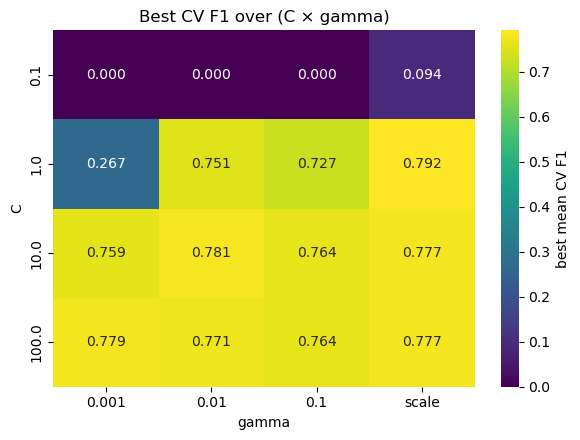

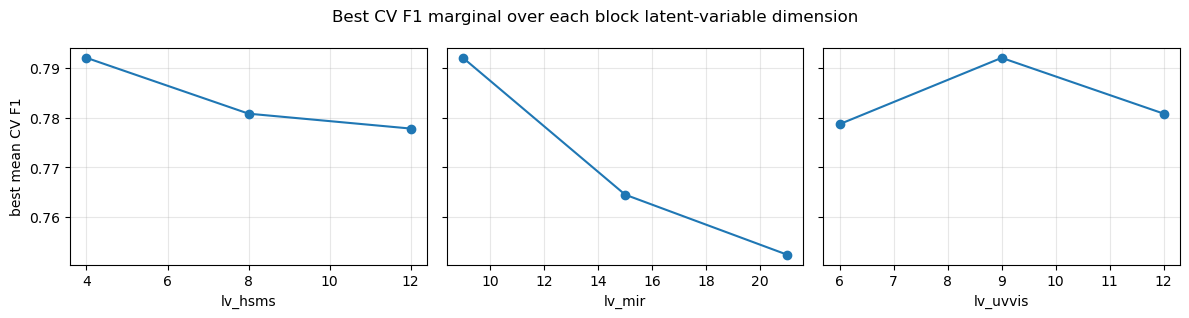

In [10]:
# (a) Heatmap: best CV F1 for each (C, gamma) pair (max over the block LVs).
piv = res.pivot_table(index="C", columns="gamma",
                      values="mean_test_score", aggfunc="max")
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(piv, annot=True, fmt=".3f", cmap="viridis", ax=ax,
            cbar_kws={"label": "best mean CV F1"})
ax.set_title("Best CV F1 over (C × gamma)")
ax.set_xlabel("gamma"); ax.set_ylabel("C")
plt.tight_layout(); plt.show()

# (b) Marginal: best CV F1 against each block LV dimension (max over the others).
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for ax, col in zip(axes, ["lv_hsms", "lv_mir", "lv_uvvis"]):
    gmax = res.groupby(col)["mean_test_score"].max()
    ax.plot(gmax.index, gmax.values, "o-")
    ax.set_xlabel(col); ax.grid(alpha=0.3)
axes[0].set_ylabel("best mean CV F1")
fig.suptitle("Best CV F1 marginal over each block latent-variable dimension")
plt.tight_layout(); plt.show()

## 8. Fine C / gamma refinement around the coarse winner

The coarse winner sat in a flat ridge of mild SVM settings, so we zoom in on the
two knobs that matter — **`C` and `gamma`** — on a finer log grid, **locking the
block latent variables** to the coarse winner. After the fused scores are
standardised, `gamma="scale"` ≈ `1 / n_features` ≈ 0.045 (with ~22 fused
features), so the numeric gammas below bracket that; `"scale"` is kept as the
reference point. Nested CV is re-run on this fine grid to keep the comparison
honest.

In [11]:
best = search.best_params_
b_components = best["n_components_list"]

# Finer log grid bracketing the coarse winner (C=1, gamma='scale' ~ 0.045).
fine_C = [0.3, 0.5, 1, 2, 3, 5]
fine_gamma = ["scale", 0.02, 0.03, 0.05, 0.07, 0.1]

fine_grid = {
    "n_components_list": [b_components],   # locked to the coarse winner
    "classifier__C": fine_C,
    "classifier__gamma": fine_gamma,
    "scale_fused": [best["scale_fused"]],
}
print("Locked block LVs:", b_components)
print("Fine C grid     :", fine_C)
print("Fine gamma grid :", fine_gamma)
print("Fine configs    :", len(fine_C) * len(fine_gamma))

Locked block LVs: (4, 9, 9)
Fine C grid     : [0.3, 0.5, 1, 2, 3, 5]
Fine gamma grid : ['scale', 0.02, 0.03, 0.05, 0.07, 0.1]
Fine configs    : 36


In [12]:
nested_fine = nested_cv(
    model, fine_grid,
    data.train_blocks(), data.y,
    outer_cv=make_cv(5, random_state=0),
    inner_cv=make_cv(3, random_state=1),
)
fine_nested_f1 = nested_fine["raw"]["test_f1"].mean()

fine_search = tune_final_model(
    model, fine_grid, data.train_blocks(), data.y, cv=make_cv(5, random_state=0),
)

print(f"Coarse nested-CV F1: {coarse_nested_f1:.3f}")
print(f"Fine   nested-CV F1: {fine_nested_f1:.3f}")
print("Fine best params   :", fine_search.best_params_)

Coarse nested-CV F1: 0.777
Fine   nested-CV F1: 0.728
Fine best params   : {'classifier__C': 1, 'classifier__gamma': 'scale', 'n_components_list': (4, 9, 9), 'scale_fused': True}


## 9. Deploy the best model

Pick whichever grid gave the better **honest (nested)** F1; its `tune_final_model`
search is already refit on all calibration data.

In [13]:
if fine_nested_f1 >= coarse_nested_f1:
    final_search, tag, headline_f1 = fine_search, "fine", fine_nested_f1
else:
    final_search, tag, headline_f1 = search, "coarse", coarse_nested_f1

print(f"Deploying the {tag}-grid model "
      f"(nested-CV F1 = {headline_f1:.3f}; params = {final_search.best_params_})")

Deploying the coarse-grid model (nested-CV F1 = 0.777; params = {'classifier__C': 1, 'classifier__gamma': 'scale', 'n_components_list': (4, 9, 9), 'scale_fused': True})


## 10. Training-set fit of the deployed model

Scores on the **calibration set it was fitted on** (resubstitution): F1, Precision,
Recall and Inaccuracy (% misclassified).

> Optimistic — the model has seen these samples. The honest generalization
> estimate stays the nested-CV F1 (§5); the gap is an overfitting diagnostic.

In [14]:
y_train_pred = final_search.predict(data.train_blocks())

train_scores = pd.DataFrame(
    {"train": [
        f1_score(data.y, y_train_pred),
        precision_score(data.y, y_train_pred),
        recall_score(data.y, y_train_pred),
        100.0 * (1.0 - accuracy_score(data.y, y_train_pred)),
    ]},
    index=["F1", "Precision", "Recall", "Inaccuracy (%)"],
)
print(f"Deployed model train-set fit (n = {len(data.y)} samples):")
display(train_scores.round(3))
print(f"For reference — honest nested-CV F1: {headline_f1:.3f}")

Deployed model train-set fit (n = 220 samples):


,train
F1,0.939
Precision,0.972
Recall,0.908
Inaccuracy (%),4.091


For reference — honest nested-CV F1: 0.777


## 11. Predict the test set

In [15]:
predictions = predict_test(final_search, data.test_blocks(), data.test_ids)
print("Predicted test balance:",
      predictions["prediction"].value_counts().sort_index().to_dict())

out_path = PROJECT_ROOT / "Data" / "predictions_02d_SVM.csv"
predictions.to_csv(out_path, index=False)
print("Saved:", out_path)
predictions

Predicted test balance: {0: 17, 1: 7}
Saved: C:\Users\SamdGuizani\OneDrive\Documents\Data Science & Coding\2026-Olive Oil Classification (CAC 2026)\CAC-2026_Data-Challenge_Olive-Oil-Sensory-Defects-Detection-Using-Chemometrics\Data\predictions_02d_SVM.csv


,sample_id,prediction,proba_musty
0,1,1,0.994793
1,2,0,0.007994
2,3,1,0.941378
3,4,0,0.099572
4,5,0,0.011647
5,6,0,0.008780
6,7,0,0.028324
7,8,1,0.724206
8,9,0,0.157373
9,10,0,0.029745


## Next steps

- Compare the deployed nested-CV F1 here against 02a PLS-DA (0.765), 02b LDA
  (0.755) and 02c QDA (0.688).
- **If SVM-RBF ≈ 0.76 too:** the classifier lever is exhausted — every head
  (linear and non-linear) lands at the same ceiling, so the limit is the
  **features**. Pivot to region / variable selection (iPLS, sparse-PLS, GA) and
  preprocessing rather than more classifiers.
- **If SVM-RBF clearly beats 0.77:** there is exploitable non-linear structure;
  refine `C` / `gamma` on a finer log grid and consider Random Forest / XGBoost.